<h1>MonReader: Single Frame Modelling (SFM): Model Training 3

<h3>Continuing SFM model training

In [1]:
from pathlib import Path
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
TRAIN_DATA_DIR = RAW_DATA_DIR / "training"
TEST_DATA_DIR = RAW_DATA_DIR / "testing"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
SFM_DATA_DIR = PROCESSED_DATA_DIR / "sfm"

MODELS_DIR = PROJ_ROOT / "models"
SFM_MODELS_DIR = MODELS_DIR / "sfm"

In [2]:
# Base
import os
import pickle
import numpy as np
import pandas as pd

# Custom
from mrp_functions import *

In [3]:
# Data Import
pkl_data = load_pickle_data(SFM_DATA_DIR)

Loaded 2 pickle files:
['sfm_processed_data_sobel', 'sfm_processed_data_gray']


In [5]:
data = pkl_data['sfm_processed_data_sobel']
print(data.keys())

dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test'])


In [6]:
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']

input_shape = X_train.shape[1:]

In [8]:
import tensorflow as tf
# CNN layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, Flatten
# Data Augmentation:
from tensorflow.keras.layers import RandomRotation, RandomTranslation, RandomZoom, RandomContrast, GaussianNoise

As eluded to in the last notebook `GlobalAveragePooling2D()` can remove information regarding feature location. Feature location is important in this project. Whilst it useful for identifying if a feature is present the removal of location information isn't good for us.

Let's train a new model identical to model_2_1 but with this model aspect removed:

- 'model_2_1' and 'model_2_2' are identical except 'model_2_2' has data augmentation (DA) implemented. Let's try without DA (model_2_3) and then with DA (model_2_4) if overfitting is still an issue.

<h3>model_2_3 (No DA)

In [9]:
model_2_3 = Sequential([
        # Input
        Input(shape=input_shape),

        # Layer 1
        Conv2D(32, 3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),

        # Layer 2
        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        # Layer 3
        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        # Removed GlobalAveragePooling2D so need a way to convert a 3D vector to a 1D vector without 'flatten' only
        # which drastically increases parameter count and could worsen overfitting:

        # Layer 3.1
        Conv2D(128, 3, padding="same", activation="relu"),
        MaxPooling2D(),
        Flatten(),
        
        # Layer 4
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        # Output
        Dense(1, activation="sigmoid")],

        name = 'model_2_3')

model_2_3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])
model_2_3.summary()

/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "model_2_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 480, 270, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 478, 268, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 239, 134, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 239, 134, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 119, 67, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 59, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 249216)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     7,974,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,169,889 (31.17 MB)

 Trainable params: 8,169,505 (31.16 MB)

 Non-trainable params: 384 (1.50 KB)

**Trained on AWS**

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-145357/model_2_3.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-145357/model_2_3_history.json'


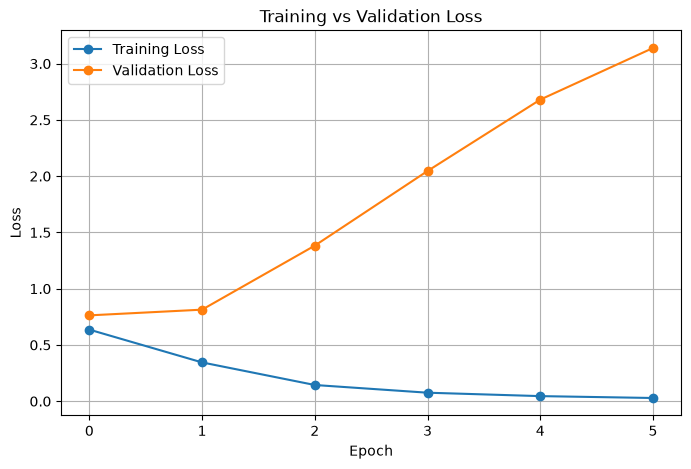

I0000 00:00:1789220201.087933 2078535 service.cc:153] XLA service 0x16e3f78d0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789220201.088224 2078535 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1789220201.180378 2078535 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1789220201.628280 2078859 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
I0000 00:00:1789220201.628862 2078859 rsqrt.cc:179] Falling back to 1 / sqrt(x) for f32 false
I0000 00:00:1789220201.701305 2078535 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Test set evaluation:
  loss: 0.7647543549537659
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

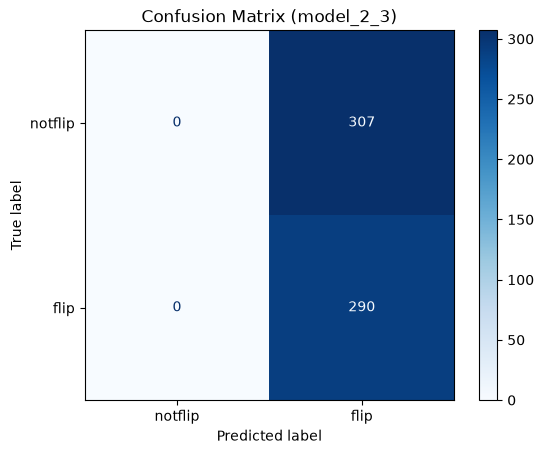

In [10]:
# Results:
train_model_2_3 = False

job_name = "tensorflow-monreader-model-20260905-145357" 
model_name = "model_2_3.keras" 
history_name = "model_2_3_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_2_3 == False:
    model_2_3,model_2_3_history =  load_model("model_2_3", AWS_MODEL_DIR)
    plot_training_history(model_2_3_history, metric='loss')


model_2_3_to_eval = model_2_3 if train_model_2_3 == False else model_2_3

# Guard against accidentally passing the training History object
if isinstance(model_2_3_to_eval, tf.keras.callbacks.History):
    model_2_3_to_eval = model_2_3

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_3_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_3"
)

Let's try with DA

<h3>model_2_4 (DA)

In [11]:
data_augmentation = tf.keras.Sequential([
    
    # Small camera/book rotation (~±3.6 degrees)
    tf.keras.layers.RandomRotation(factor=0.01,fill_mode="reflect"),

    # Move image slightly vertically/horizontally
    tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor=0.05,fill_mode="reflect"),

    # Slight variation in camera distance
    tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode="reflect"),

    # Small contrast variation
    tf.keras.layers.RandomContrast(factor=0.10),

    # Simulate small amounts of camera/sensor noise
    tf.keras.layers.GaussianNoise(stddev=0.015)
])

In [12]:
model_2_4 = Sequential([
        # Input
        Input(shape=input_shape),

        data_augmentation,

        # Layer 1
        Conv2D(32, 3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),

        # Layer 2
        Conv2D(32, 3, activation="relu"),
        MaxPooling2D(),
        Dropout(0.2),

        # Layer 3
        Conv2D(128, 3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling2D(),
        Dropout(0.2),

        # Removed GlobalAveragePooling2D so need a way to convert a 3D vector to a 1D vector without 'flatten' only
        # which drastically increases parameter count and could worsen overfitting:

        # Layer 3.1
        Conv2D(128, 3, padding="same", activation="relu"),
        MaxPooling2D(),
        Flatten(),
        
        # Layer 4
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        # Output
        Dense(1, activation="sigmoid")],

        name = 'model_2_4')

model_2_4.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])
model_2_4.summary()

/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "model_2_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 480, 270, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 480, 270, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 478, 268, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 239, 134, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 239, 134, 128)  │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 239, 134, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 119, 67, 128)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 119, 67, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 59, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 249216)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │     7,974,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,169,889 (31.17 MB)

 Trainable params: 8,169,505 (31.16 MB)

 Non-trainable params: 384 (1.50 KB)

**Trained on AWS**

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-151631/model_2_4.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-151631/model_2_4_history.json'


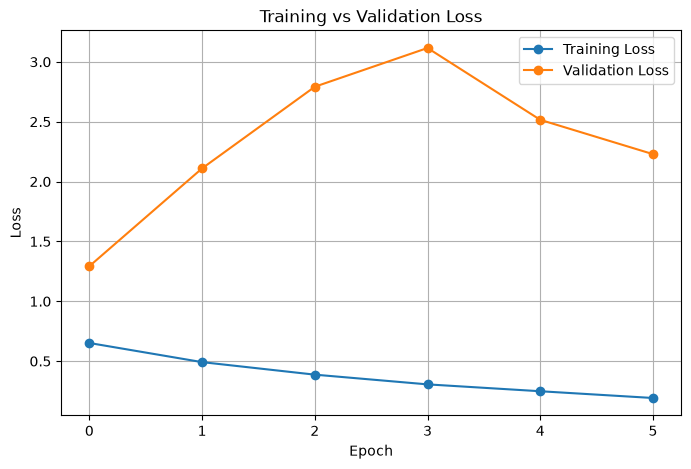

Test set evaluation:
  loss: 1.295193076133728
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

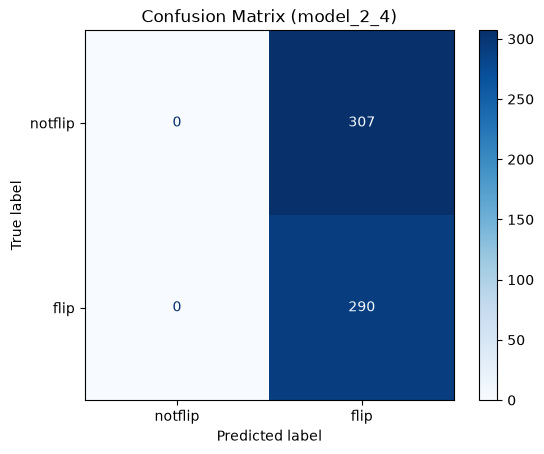

In [13]:
# Results:
train_model_2_4 = False

job_name = "tensorflow-monreader-model-20260905-151631" 
model_name = "model_2_4.keras" 
history_name = "model_2_4_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_2_4 == False:
    model_2_4,model_2_4_history =  load_model("model_2_4", AWS_MODEL_DIR)
    plot_training_history(model_2_4_history, metric='loss')


model_2_4_to_eval = model_2_4 if train_model_2_4 == False else model_2_4

# Guard against accidentally passing the training History object
if isinstance(model_2_4_to_eval, tf.keras.callbacks.History):
    model_2_4_to_eval = model_2_4

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_2_4_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_2_4"
)

Still not great. What to do next?

1. Let's look at the predicted probabilities distribution:

In [14]:
y_prob = model_2_4_to_eval.predict(X_test).ravel()

print("Minimum:", y_prob.min())
print("Maximum:", y_prob.max())
print("Mean:", y_prob.mean())

print(np.percentile(
    y_prob,
    [0, 5, 25, 50, 75, 95, 100]
))

19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 759ms/step
Minimum: 0.9108992
Maximum: 0.91395503
Mean: 0.91229194
[0.91089922 0.91132017 0.91179591 0.91225356 0.91273886 0.91344925
 0.91395503]


*It has collapsed strongly towards class 1*

2. Verify class counts:

In [15]:
for name, y in [
    ("train", y_train),
    ("val", y_val),
    ("test", y_test)
]:
    values, counts = np.unique(y, return_counts=True)

    print(name)
    print(dict(zip(values, counts)))

train
{np.int64(0): np.int64(984), np.int64(1): np.int64(929)}
val
{np.int64(0): np.int64(246), np.int64(1): np.int64(233)}
test
{np.int64(0): np.int64(307), np.int64(1): np.int64(290)}


3. Make sure labels are correct/consistent:

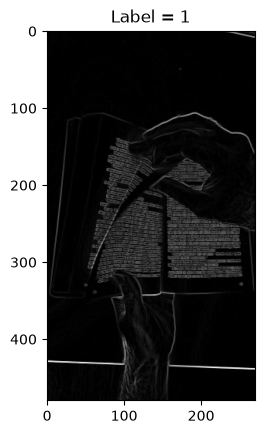

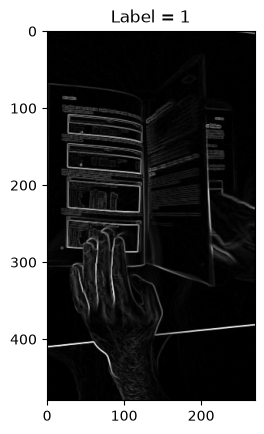

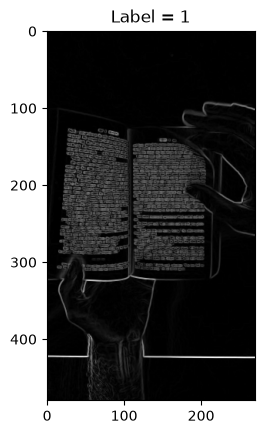

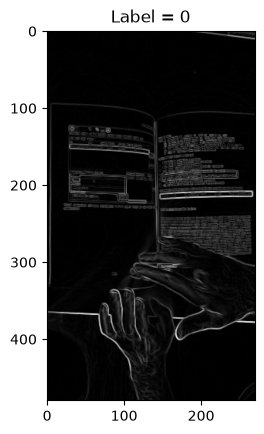

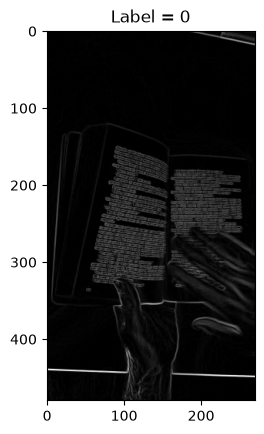

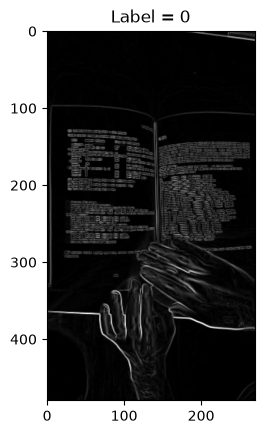

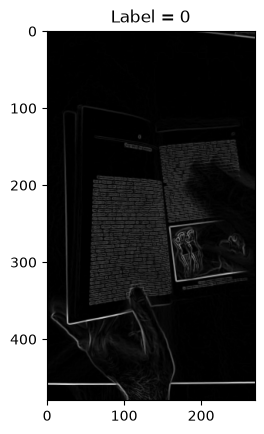

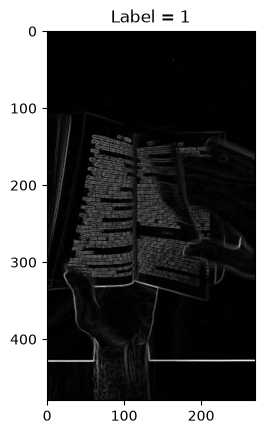

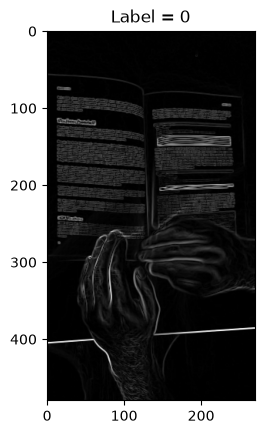

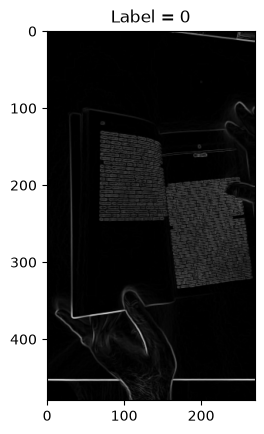

In [16]:
for i in range(10):

    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(f"Label = {y_train[i]}")
    plt.show()

Something that could be done is feeding two channels instead of one to the model, one grey scale and the other Sobel. This may allow info lost during Sobel transformation to be used alongside the most important information retained in the Sobel images.

<h3>model_3

We need to fix overfitting whilst also trying to address the model's poor feature distinction behaviour.

My main concern is that due to the spatial nature of features that distinguish between the two classes the models so far may not be set-up properly for spatial feature recognition.

In [17]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import SpatialDropout2D

In [18]:
data_augmentation = tf.keras.Sequential([
    
        # Small camera/book rotation (~±3.6 degrees)
        tf.keras.layers.RandomRotation(factor=0.01,fill_mode="reflect"),

        # Move image slightly vertically/horizontally
        tf.keras.layers.RandomTranslation(height_factor=0.05,width_factor=0.05,fill_mode="reflect"),

        # Slight variation in camera distance
        tf.keras.layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05), fill_mode="reflect"),

        # Small contrast variation
        tf.keras.layers.RandomContrast(factor=0.10),

        # Simulate small amounts of camera/sensor noise
        tf.keras.layers.GaussianNoise(stddev=0.015)
        ])

In [19]:
model_3 = Sequential([

    Input(shape=input_shape),

    data_augmentation,

    # Block 1 - basic edges / textures
    Conv2D(32,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(32,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    MaxPooling2D(),
    SpatialDropout2D(0.10),

    # Block 2 - edge combinations / shapes
    Conv2D(64,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(64,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    MaxPooling2D(),
    SpatialDropout2D(0.15),

    # Block 3 - page / hand structures
    Conv2D(128,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Conv2D(128,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    MaxPooling2D(),
    SpatialDropout2D(0.20),
    
    # Block 4 - higher-level spatial patterns
    Conv2D(128,3,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(),

    # Spatial bottleneck:
    # Reduce 128 channels to 16 while retaining the H x W spatial grid.
    Conv2D(16,1,padding="same",activation="relu",kernel_regularizer=l2(1e-4)),

    # Further spatial reduction before Flatten
    MaxPooling2D(),

    # Classifier
    Flatten(),
    Dense(32,activation="relu",kernel_regularizer=l2(1e-4)),
    Dropout(0.4),
    Dense(1,activation="sigmoid")

],
name = 'model_3')

model_3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")])
model_3.summary()

Model: "model_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 480, 270, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 480, 270, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 480, 270, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 480, 270, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 240, 135, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 240, 135, 32)   │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 240, 135, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 240, 135, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 240, 135, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 120, 67, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 120, 67, 64)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 120, 67, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 120, 67, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 120, 67, 128)   │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 60, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 60, 33, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 33, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 60, 33, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 30, 16, 16)     │         2,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 8, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 498,993 (1.90 MB)

 Trainable params: 498,289 (1.90 MB)

 Non-trainable params: 704 (2.75 KB)

- More layers have been added to give the model opportunity to build features hierarchially.
- `SpatialDropout2D()` is used instead of `Dropout()` in some places. Rather than randomly deleting individual pixels from feature maps, it removes entire learned feature channels.
- L2 regularisation has been added to penalize large weights because we are working with a small dataset.
- The parameters appear to be more evenly spread out over the model. This may help with overfitting?

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-184936/model_3.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260905-184936/model_3_history.json'


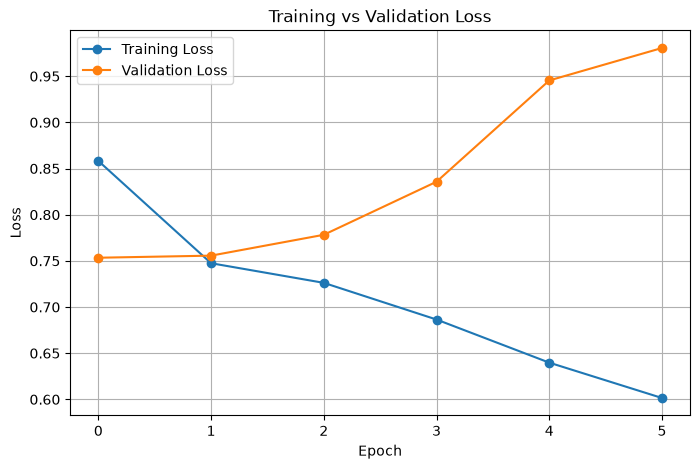

Test set evaluation:
  loss: 0.7534447312355042
  compile_metrics: 0.4857621490955353

Classification Report:
              precision    recall  f1-score   support

     notflip       0.00      0.00      0.00       307
        flip       0.49      1.00      0.65       290

    accuracy                           0.49       597
   macro avg       0.24      0.50      0.33       597
weighted avg       0.24      0.49      0.32       597

Macro F1-score: 0.3269


/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

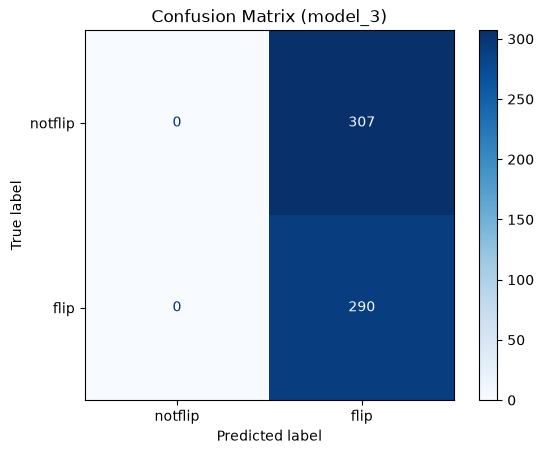

In [20]:
# Results:
train_model_3 = False

job_name = "tensorflow-monreader-model-20260905-184936" 
model_name = "model_3.keras" 
history_name = "model_3_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_3 == False:
    model_3,model_3_history =  load_model("model_3", AWS_MODEL_DIR)
    plot_training_history(model_3_history, metric='loss')


model_3_to_eval = model_3 if train_model_3 == False else model_3

# Guard against accidentally passing the training History object
if isinstance(model_3_to_eval, tf.keras.callbacks.History):
    model_3_to_eval = model_3

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_3_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_3"
)

Still poor predictions, but the degree of the overfitting is less which is good. Need to tune further. How about we try using the grayscale (non-Sobel) images to see if that makes a difference with the new model structure (model_3_2). The Sobel image processing may have removed too much information.

In [22]:
# Data Import
pkl_data = load_pickle_data(SFM_DATA_DIR)
pkl_data = pkl_data['sfm_processed_data_gray']

Loaded 2 pickle files:
['sfm_processed_data_sobel', 'sfm_processed_data_gray']


In [23]:
X_train_gray = pkl_data['X_train']
X_test_gray = pkl_data['X_test']
y_train_gray = pkl_data['y_train']
y_test_gray = pkl_data['y_test']

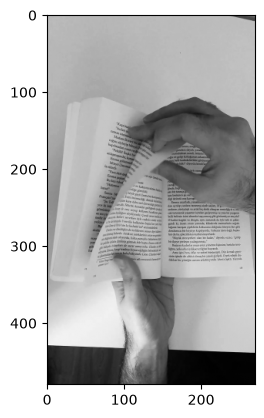

In [24]:
plt.imshow(X_train_gray[0].squeeze(), cmap="gray")

In [25]:
X_train_gray[0].shape

(480, 270, 1)

In [26]:
type(X_train_gray)

numpy.ndarray

- Images already normalised.
- Already shrunk.
- Already numpy arrays.
- Let's quickly shuffle the training data and then create validation sets

In [27]:
X_train_gray, y_train_gray = shuffle_data(X_train_gray, y_train_gray)
X_train_gray, X_val_gray, y_train_gray, y_val_gray = create_validation_set(X_train_gray, y_train_gray)

In [28]:
# Package into a dictionary ready for S3 upload:
processed_data_gray = {
    "X_train": np.asarray(X_train_gray, dtype=np.float32),
    "y_train": np.asarray(y_train_gray),
    "X_val": np.asarray(X_val_gray, dtype=np.float32),
    "y_val": np.asarray(y_val_gray),
    "X_test": np.asarray(X_test_gray, dtype=np.float32),
    "y_test": np.asarray(y_test_gray),
}

processed_data_path_gray = SFM_DATA_DIR / "sfm_processed_data_gray.pkl"

with open(processed_data_path_gray, "wb") as file:
    pickle.dump(processed_data_gray, file)

In [29]:
processed_data_gray.keys()

dict_keys(['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test'])

Same model structure as model_3. Evaluation of model_3_2:

In [30]:
X_test = X_test_gray
y_test = y_test_gray

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260906-155530/model_3_2.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260906-155530/model_3_2_history.json'


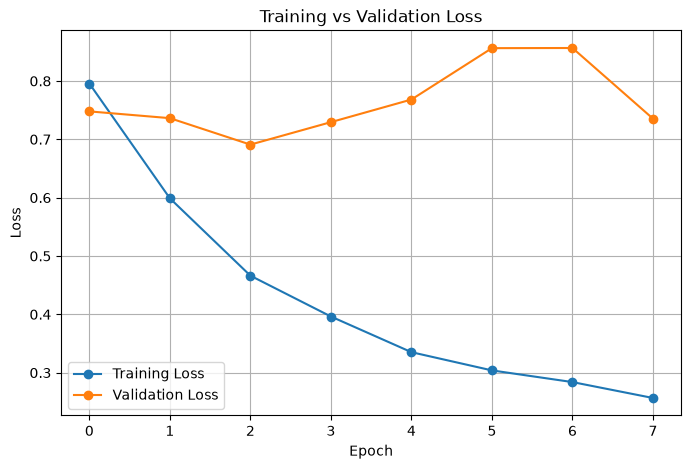

Test set evaluation:
  loss: 0.6860998868942261
  compile_metrics: 0.7018425464630127

Classification Report:
              precision    recall  f1-score   support

     notflip       0.72      0.68      0.70       307
        flip       0.68      0.72      0.70       290

    accuracy                           0.70       597
   macro avg       0.70      0.70      0.70       597
weighted avg       0.70      0.70      0.70       597

Macro F1-score: 0.7018


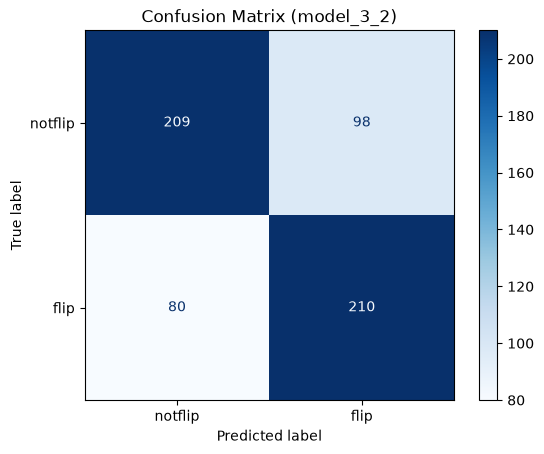

In [31]:
# Results:
train_model_3_2 = False

job_name = "tensorflow-monreader-model-20260906-155530" 
model_name = "model_3_2.keras" 
history_name = "model_3_2_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_3_2 == False:
    model_3_2,model_3_2_history =  load_model("model_3_2", AWS_MODEL_DIR)
    plot_training_history(model_3_2_history, metric='loss')


model_3_2_to_eval = model_3_2 if train_model_3_2 == False else model_3_2

# Guard against accidentally passing the training History object
if isinstance(model_3_2_to_eval, tf.keras.callbacks.History):
    model_3_2_to_eval = model_3_2

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_3_2_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_3_2"
)

Ok, we now have the model making distinguishemnts, and with an F1-score of 70%. I think using grayscale is the way forward. This also confirms my suspiciion that the Sobel processing was removing useful information.

 Something I noticed about the model training was the decrease in val loss at epoch 7. The early stopping kicked in at epoch 8 and restored the weights of epoch 3. We are still seeing overfitting. Is it worth training using 10 instead of 5 as the patience to see how it behaves, and give it a chance to improve?

Loaded model from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260906-184905\model_3_2_2.keras'
Loaded history from 'C:\Users\cochr\Data Science Projects\gejIeSjwpDqobLkc\models\sfm\aws_trained\tensorflow-monreader-model-20260906-184905\model_3_2_2_history.json'


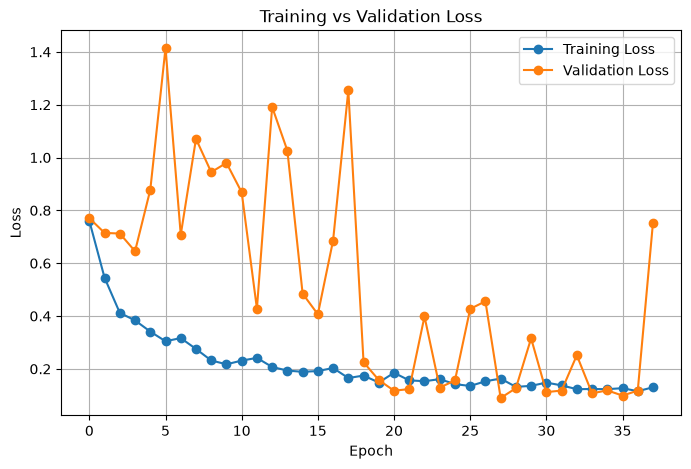

Test set evaluation:
  loss: 0.10527386516332626
  compile_metrics: 0.9765493869781494

Classification Report:
              precision    recall  f1-score   support

     notflip       0.99      0.97      0.98       307
        flip       0.97      0.99      0.98       290

    accuracy                           0.98       597
   macro avg       0.98      0.98      0.98       597
weighted avg       0.98      0.98      0.98       597

Macro F1-score: 0.9765


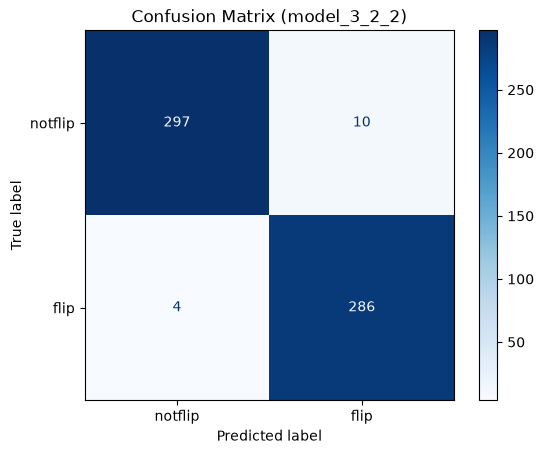

In [ ]:
# model 3_2_2: Early stopping patience = 10. Number of epochs = 100
train_model_3_2_2 = False

job_name = "tensorflow-monreader-model-20260906-184905" 
model_name = "model_3_2_2.keras" 
history_name = "model_3_2_2_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_3_2_2 == False:
    model_3_2_2,model_3_2_2_history =  load_model("model_3_2_2", AWS_MODEL_DIR)
    plot_training_history(model_3_2_2_history, metric='loss')


model_3_2_2_to_eval = model_3_2_2 if train_model_3_2_2 == False else model_3_2_2

# Guard against accidentally passing the training History object
if isinstance(model_3_2_2_to_eval, tf.keras.callbacks.History):
    model_3_2_2_to_eval = model_3_2_2

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_3_2_2_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_3_2_2"
)


It looks like the 5 instead of 10 patience for early stopping was limiting it. 

**98% F1-score???**

The model is already pretty good. I've noticed some erratic behaviour in the val_loss. We could try to reduce the learning rate (LR) on plateau (RLROP) to perhaps deal with it. It's not necessarily a massive issue because early stopping restored the weights to a good epoch giving high val and test evaluation scores.

The following callback can be implemented alongside early stopping for this purpose:

In [33]:
tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    cooldown=1,
    verbose=1
)

- Factor = 0.5 : The LR is reduced by a half on plateau
- Others are self-explanatory...

Loaded model from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260912-141534/model_3_2_3.keras'
Loaded history from '/Users/cameroncochrane/Data Projects/gejIeSjwpDqobLkc/models/sfm/aws_trained/tensorflow-monreader-model-20260912-141534/model_3_2_3_history.json'


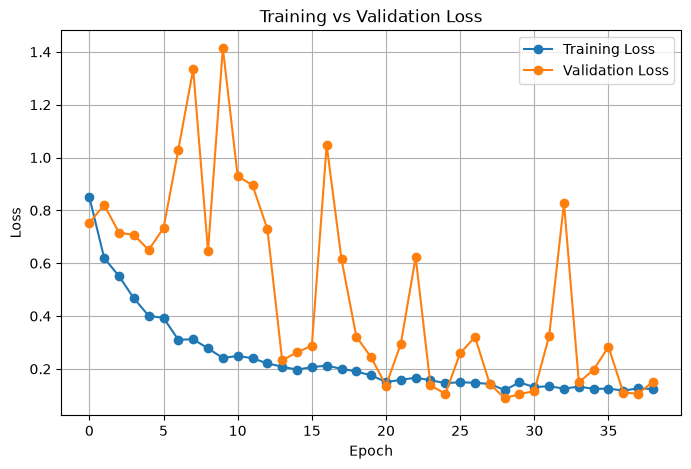

Test set evaluation:
  loss: 0.09105833619832993
  compile_metrics: 0.9899497628211975

Classification Report:
              precision    recall  f1-score   support

     notflip       0.99      0.99      0.99       307
        flip       0.99      0.99      0.99       290

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597

Macro F1-score: 0.9899


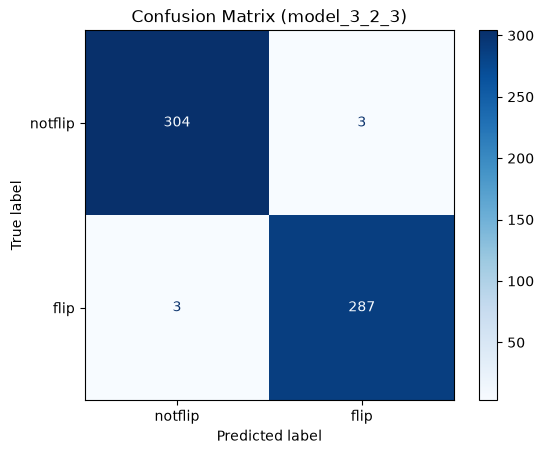

In [34]:
# model 3_2_3: Early stopping patience = 10. Number of epochs = 100 + ReduceLRonPlateau (patience = 10):

train_model_3_2_3 = False

job_name = "tensorflow-monreader-model-20260912-141534" 
model_name = "model_3_2_3.keras" 
history_name = "model_3_2_3_history.json"

SFM_AWS_MODELS_DIR = SFM_MODELS_DIR / "aws_trained"
AWS_MODEL_DIR = SFM_AWS_MODELS_DIR / job_name


if train_model_3_2_3 == False:
    model_3_2_3,model_3_2_3_history =  load_model("model_3_2_3", AWS_MODEL_DIR)
    plot_training_history(model_3_2_3_history, metric='loss')


model_3_2_3_to_eval = model_3_2_3 if train_model_3_2_3 == False else model_3_2_3

# Guard against accidentally passing the training History object
if isinstance(model_3_2_3_to_eval, tf.keras.callbacks.History):
    model_3_2_3_to_eval = model_3_2_3

# Ensure rank is known and the arrays are concrete numpy arrays
X_eval = np.asarray(X_test, dtype=np.float32)
y_eval = np.asarray(y_test, dtype=np.int32).reshape(-1)

eval_results = evaluate_model(
    model_3_2_3_to_eval,
    X_eval,
    y_eval,
    class_names=('notflip', 'flip'),
    plot_name="model_3_2_3"
)

Model looks the same because RLROP didn't kick in. The evaluation metrics are still very good however, with no signs of overfitting (this model has the weights of epoch # 29, the best epoch).